In [3]:
import os
import cv2
import numpy as np
from sklearn.preprocessing import MinMaxScaler


In [4]:
def extract_features(image_path, num_features=4):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (64, 64))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    features = [
        np.mean(gray),
        np.std(gray),
        np.max(gray),
        np.min(gray)
    ]

    return np.array(features[:num_features])


In [5]:
def load_dataset(image_dir, label_dir, num_features=4):
    X, y = [], []

    for file in os.listdir(image_dir):
        if file.endswith(".jpg") or file.endswith(".png"):
            img_path = os.path.join(image_dir, file)
            label_file = file.replace(".jpg", ".txt").replace(".png", ".txt")
            label_path = os.path.join(label_dir, label_file)

            if not os.path.exists(label_path):
                continue

            with open(label_path, "r") as f:
                class_id = int(f.readline().split()[0])

            X.append(extract_features(img_path, num_features))
            y.append(class_id)

    return np.array(X), np.array(y)


In [6]:
train_images = r"C:\Users\KIIT0001\Desktop\Riju\quantum computing\code\archive\train\images"
train_labels = r"C:\Users\KIIT0001\Desktop\Riju\quantum computing\code\archive\train\labels"

valid_images = r"C:\Users\KIIT0001\Desktop\Riju\quantum computing\code\archive\valid\images"
valid_labels = r"C:\Users\KIIT0001\Desktop\Riju\quantum computing\code\archive\valid\labels"

test_images = r"C:\Users\KIIT0001\Desktop\Riju\quantum computing\code\archive\test\images"
test_labels = r"C:\Users\KIIT0001\Desktop\Riju\quantum computing\code\archive\test\labels"

X_train, y_train = load_dataset(train_images, train_labels)
X_valid, y_valid = load_dataset(valid_images, valid_labels)
X_test, y_test = load_dataset(test_images, test_labels)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

print(X_train.shape, X_test.shape)

# 🔴 LIMIT DATA SIZE FOR QUANTUM TRAINING
X_train = X_train[:20]
y_train = y_train[:20]

X_test = X_test[:10]
y_test = y_test[:10]

print("Reduced training size:", X_train.shape)



(13605, 4) (1717, 4)
Reduced training size: (20, 4)


In [7]:
from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC

feature_map = ZZFeatureMap(feature_dimension=4, reps=2)
quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)

qsvc = QSVC(quantum_kernel=quantum_kernel)
print("Starting QSVC training...")
qsvc.fit(X_train, y_train)
print("QSVC training completed")


print("QSVC Accuracy:", qsvc.score(X_test, y_test))


Starting QSVC training...
QSVC training completed
QSVC Accuracy: 0.1


In [12]:
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.algorithms import VQC
from qiskit_algorithms.optimizers import COBYLA
from qiskit_aer.primitives import Estimator


In [13]:
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_machine_learning.algorithms import VQC
from qiskit_algorithms.optimizers import COBYLA
from qiskit_aer import Aer

num_qubits = 4

feature_map = ZZFeatureMap(feature_dimension=num_qubits, reps=2)
ansatz = RealAmplitudes(num_qubits=num_qubits, reps=2)

backend = Aer.get_backend("aer_simulator_statevector")
optimizer = COBYLA(maxiter=100)

vqc = VQC(
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=optimizer,
    quantum_instance=backend
)

vqc.fit(X_train, y_train)
print("Train accuracy:", vqc.score(X_train, y_train))
print("Test accuracy :", vqc.score(X_test, y_test))
y_train = y_train.astype(int)
y_test  = y_test.astype(int)


Train accuracy: 0.75
Test accuracy : 0.5


In [8]:
np.unique(y_train)


array([ 6, 14, 15, 16, 17, 18, 19, 21, 22, 23, 24, 25, 26])

In [9]:
y_train = y_train % 2
y_test  = y_test % 2


In [10]:
X_train.shape  # ≤ 20 samples is good


(20, 4)

In [11]:
num_qubits = 4
X_train.shape[1] == 4


True

In [14]:
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
import matplotlib.pyplot as plt

num_qubits = 4

feature_map = ZZFeatureMap(feature_dimension=num_qubits, reps=2)
ansatz = RealAmplitudes(num_qubits=num_qubits, reps=2)

vqc_circuit = feature_map.compose(ansatz)

vqc_circuit.draw("mpl")
plt.show()


c:\Users\KIIT0001\anaconda3\envs\cwq_qiskit\lib\site-packages\qiskit\visualization\circuit\matplotlib.py:266: FutureWarning: The default matplotlib drawer scheme will be changed to "iqp" in a following release. To silence this warning, specify the current default explicitly as style="clifford", or the new default as style="iqp".
  self._style, def_font_ratio = load_style(self._style)


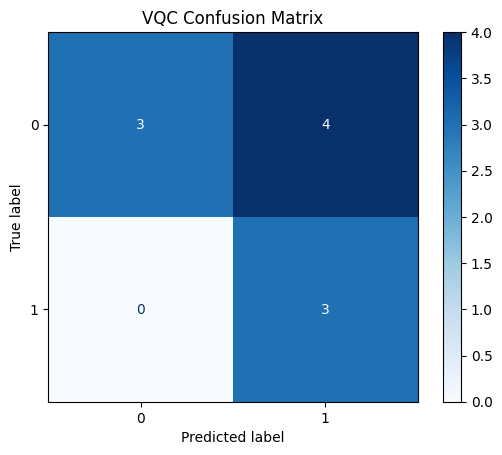

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_vqc = vqc.predict(X_test)

cm = confusion_matrix(y_test, y_pred_vqc)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")
plt.title("VQC Confusion Matrix")
plt.show()


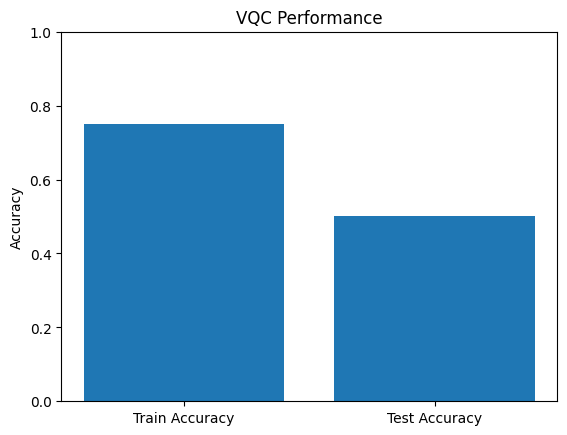

In [16]:
import matplotlib.pyplot as plt

train_acc = vqc.score(X_train, y_train)
test_acc = vqc.score(X_test, y_test)

plt.bar(["Train Accuracy", "Test Accuracy"], [train_acc, test_acc])
plt.ylabel("Accuracy")
plt.title("VQC Performance")
plt.ylim(0, 1)
plt.show()


In [17]:
from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC

feature_map = ZZFeatureMap(feature_dimension=4, reps=2)
quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)

qsvc = QSVC(quantum_kernel=quantum_kernel)
qsvc.fit(X_train, y_train)

qsvc_acc = qsvc.score(X_test, y_test)
vqc_acc = vqc.score(X_test, y_test)

print("QSVC Accuracy:", qsvc_acc)
print("VQC Accuracy:", vqc_acc)


QSVC Accuracy: 0.6
VQC Accuracy: 0.5


In [18]:
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
import matplotlib.pyplot as plt

num_qubits = 4

# Build VQC circuit
feature_map = ZZFeatureMap(feature_dimension=num_qubits, reps=2)
ansatz = RealAmplitudes(num_qubits=num_qubits, reps=2)
vqc_circuit = feature_map.compose(ansatz)

# Draw and save
fig = vqc_circuit.draw(
    output="mpl",
    fold=30,
    style={"backgroundcolor": "#FFFFFF"}
)

# SAVE IMAGE
plt.savefig("VQC_Circuit.png", dpi=300, bbox_inches="tight")
plt.show()


<Figure size 640x480 with 0 Axes>

In [20]:
import os
print(os.getcwd())


c:\Users\KIIT0001\Desktop\Riju\quantum computing\code


In [21]:
plt.savefig("VQC_Circuit.pdf", bbox_inches="tight")


<Figure size 640x480 with 0 Axes>

In [22]:
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes

num_qubits = 4

# Build the VQC circuit
feature_map = ZZFeatureMap(feature_dimension=num_qubits, reps=2)
ansatz = RealAmplitudes(num_qubits=num_qubits, reps=2)
vqc_circuit = feature_map.compose(ansatz)

# Draw circuit and CAPTURE the figure
fig = vqc_circuit.draw(
    output="mpl",
    fold=30
)

# ✅ SAVE USING THE FIGURE OBJECT
fig.savefig("VQC_Circuit.png", dpi=300, bbox_inches="tight")

# Optional: also save as PDF (BEST for IEEE)
fig.savefig("VQC_Circuit.pdf", bbox_inches="tight")


c:\Users\KIIT0001\anaconda3\envs\cwq_qiskit\lib\site-packages\qiskit\visualization\circuit\matplotlib.py:266: FutureWarning: The default matplotlib drawer scheme will be changed to "iqp" in a following release. To silence this warning, specify the current default explicitly as style="clifford", or the new default as style="iqp".
  self._style, def_font_ratio = load_style(self._style)


(-0.5, 2268.5, 908.5, -0.5)

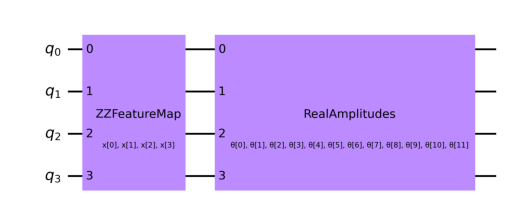

In [23]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("VQC_Circuit.png")
plt.imshow(img)
plt.axis("off")
